##CARGA DEL DATASET

Se utiliza kagglehub para descargar y cargar directamente el dataset en formato pandas

In [2]:
!pip install kagglehub[pandas-datasets]

In [3]:
import os
# Requiere configurar la variable de entorno KAGGLE_API_TOKEN
os.environ["KAGGLE_API_TOKEN"] = ""

In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "heemalichaudhari/airlines-delay",
    "DelayedFlights.csv"
)

df.shape

Using Colab cache for faster access to the 'airlines-delay' dataset.


(1936758, 30)

##LIMPIEZA INICIAL


In [5]:
import pandas as pd

In [6]:
#Elimina Columna Técnica
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df.shape

(1936758, 29)

In [7]:
#Elimina vuelo no operativo
df = df[df["Cancelled"] == 0]
df.shape

(1936125, 29)

In [8]:
#Elimina vuelos cancelados o no operativos
df = df.dropna(subset=[
    "ArrDelay",
    "ActualElapsedTime",
    "AirTime",
    "DepDelay"
])
df.shape

(1928371, 29)

##ELIMINACIÓN DE DUPLICADOS

In [9]:
#Define Vuelo único
subset_cols = [
    "Year",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "UniqueCarrier",
    "FlightNum",
    "Origin",
    "Dest",
    "CRSDepTime",
    "CRSArrTime"
]

In [10]:
#Elimina vuelos duplicados
df = df.drop_duplicates(subset=subset_cols)
df.shape

(1928369, 29)

##DEFINICIÓN DEL TARGET

Creamos la variable objetivo: 1 si el vuelo se atrasa más de 15 minutos.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

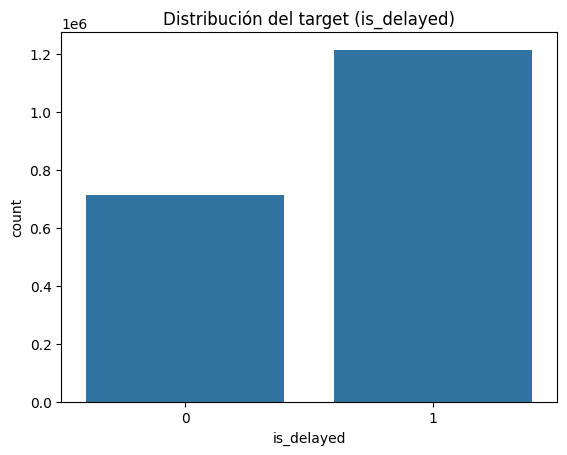

In [12]:
#Definimos target
df["is_delayed"] = (df["ArrDelay"] > 15).astype(int)

df["is_delayed"].value_counts(normalize=True)

sns.countplot(x="is_delayed", data=df)
plt.title("Distribución del target (is_delayed)")
plt.show()

##SELECCIÓN DE VARIABLES CANDIDATAS

Seleccionamos solo variables disponibles antes del despegue

In [13]:
df.columns

Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime',
       'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum',
       'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
       'is_delayed'],
      dtype='object')

In [14]:
features = [
    "UniqueCarrier",
    "Origin",
    "Dest",
    "CRSDepTime",
    "DayOfWeek",
    "Distance"
]

df = df[features + ["is_delayed"]]
df.head()


,UniqueCarrier,Origin,Dest,CRSDepTime,DayOfWeek,Distance,is_delayed
0,WN,IAD,TPA,1955,4,810,0
1,WN,IAD,TPA,735,4,810,0
2,WN,IND,BWI,620,4,515,0
3,WN,IND,BWI,1755,4,515,1
4,WN,IND,JAX,1915,4,688,0


##FEATURE ENGINEERING

CRSDepTime viene en formato HHMM, por lo que usamos división entera

In [15]:
#Transforma la hora programada de salida a hora del día
df["dep_hour"] = df["CRSDepTime"] // 100

##SEPARACIÓN DE TIPOS DE VARIABLES

In [16]:
categorical_cols = ["UniqueCarrier", "Origin", "Dest", "DayOfWeek"]
numerical_cols = ["dep_hour", "Distance"]

##PIPELINE DE TRANSFORMACIÓN

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)


In [19]:
X = preprocessor.fit_transform(df.drop(columns=["is_delayed"]))
y = df["is_delayed"]

In [20]:
feature_names = preprocessor.get_feature_names_out()

X_array = X.toarray() if hasattr(X, "toarray") else X
X_df = pd.DataFrame(X_array, columns=feature_names)

X_df.head()


,cat__UniqueCarrier_9E,cat__UniqueCarrier_AA,cat__UniqueCarrier_AQ,cat__UniqueCarrier_AS,cat__UniqueCarrier_B6,cat__UniqueCarrier_CO,cat__UniqueCarrier_DL,cat__UniqueCarrier_EV,cat__UniqueCarrier_F9,cat__UniqueCarrier_FL,...,cat__Dest_YUM,cat__DayOfWeek_1,cat__DayOfWeek_2,cat__DayOfWeek_3,cat__DayOfWeek_4,cat__DayOfWeek_5,cat__DayOfWeek_6,cat__DayOfWeek_7,num__dep_hour,num__Distance
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,19.0,810.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,7.0,810.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,6.0,515.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,17.0,515.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,19.0,688.0


In [21]:
X_df.shape, y.value_counts(normalize=True)

((1928369, 634),
 is_delayed
 1    0.630071
 0    0.369929
 Name: proportion, dtype: float64)

##CONCLUSIÓN

En este notebook se construyó el pipeline de feature engineering que permite transformar los datos crudos de vuelos en un conjunto de variables listo para modelar el atraso de un vuelo antes de su despegue.

Se limpiaron y filtraron los registros inválidos, se definió el target is_delayed usando un umbral operacional (>15 minutos), y se seleccionaron únicamente variables disponibles previo al vuelo, evitando fuga de información.

Finalmente, se implementó un ColumnTransformer con OneHotEncoder para variables categóricas y passthrough para numéricas, asegurando trazabilidad de features y consistencia entre entrenamiento y producción.

Este pipeline queda preparado para ser reutilizado directamente en el modelado y en la API de predicción, garantizando un flujo de datos coherente y reproducible de extremo a extremo.